In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
import os
os.getcwd()

'C:\\Users\\tejas'

In [4]:
import os
os.listdir()

['.anaconda',
 '.antigravity',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.gemini',
 '.gitconfig',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.packettracer',
 '.spyder-py3',
 '.virtual_documents',
 '.vscode',
 '.vscode-shared',
 '226Y1A6602- Sentence Tokenization.ipynb',
 '226Y1A6602- StopWords.ipynb',
 '226Y1A6602- Word Tokenization.ipynb',
 '226Y1A6685 - WSD.ipynb',
 '226Y1A6690 Lemmatization.ipynb',
 '226Y1A6690 POS tag.ipynb',
 '226Y1A6690.ipynb',
 '6602 lab exam.ipynb',
 '6602.ipynb',
 '6690.ipynb',
 'accenture practice.ipynb',
 'AppData',
 'Application Data',
 'Basic python in 360.ipynb',
 'Cisco Packet Tracer 8.2.2',
 'code for resume',
 'code for the resume.ipynb',
 'Contacts',
 'Cookies',
 'DA LAB SS.ipynb',
 'DA lab.ipynb',
 'DATA ANALYTICS TASK 1.ipynb',
 'Data_analytics.ipynb',
 'desktop.ipynb',
 'Documents',
 'Downloads',
 'Dropbox',
 'Favorites',
 'food_delivery.zip',
 'intenship.ipynb',
 'Links',
 'Local Settings',
 'Microso

In [5]:
df = pd.read_csv(r"D:\store_customers.csv")

# Display the first 5 rows

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


# Observation:

The dataset contains customer demographic information along with their annual income and spending score, which will be used for customer segmentation.

# Check Dataset Shape

In [8]:
df.shape

(1000, 5)

# Observation:

The dataset contains 1000 rows and 5 columns.

# Check Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


# Observation:

The dataset contains one categorical column (Gender) and four numerical columns. The data types are appropriate for analysis.

# Check Missing Values

In [10]:
df.isnull().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

# Observation:

Observation: The dataset contains missing values in the Gender, Age, Annual Income, and Spending Score columns. These missing values will be handled before performing customer segmentation.

# Descriptive Statistics

In [11]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


# Observation:

The descriptive statistics summarize the customers' age, annual income, and spending score, helping us understand the overall distribution of the data.

# Handle Missing Values

In [12]:
# Fill missing values

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

df['Age'] = df['Age'].fillna(df['Age'].median())

df['Annual Income (k$)'] = df['Annual Income (k$)'].fillna(df['Annual Income (k$)'].median())

df['Spending Score (1-100)'] = df['Spending Score (1-100)'].fillna(df['Spending Score (1-100)'].median())

In [13]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Observation:
All missing values have been handled using appropriate imputation techniques. The dataset is now complete and ready for customer segmentation analysis.

# Gender Distribution

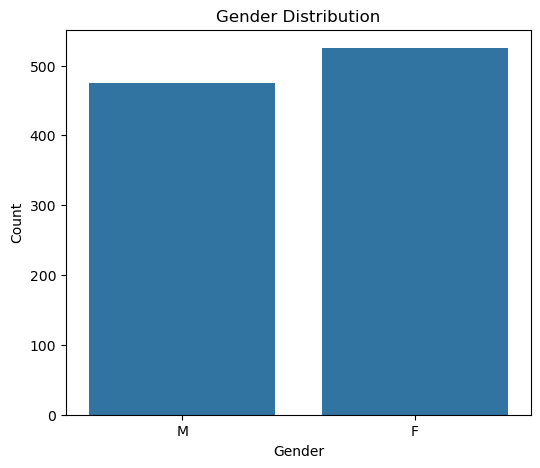

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

# Observation: 
The chart shows the distribution of male and female customers. This helps understand the gender composition of the customer base.

# Age Distribution

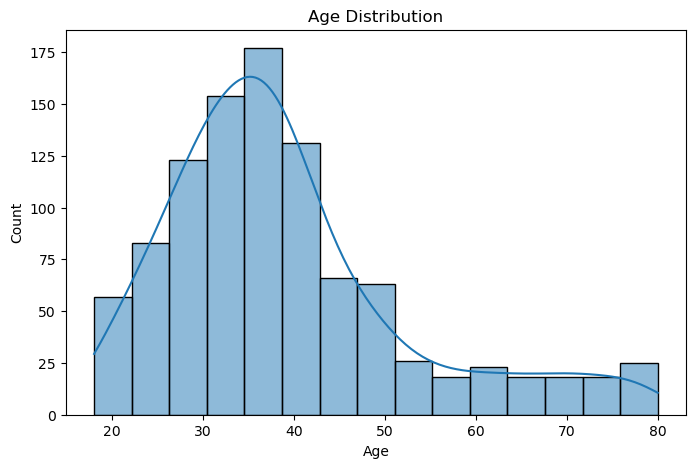

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

# Observation:
Most customers belong to the adult age group, indicating that the store primarily attracts middle-aged customers.

# Annual Income Distribution

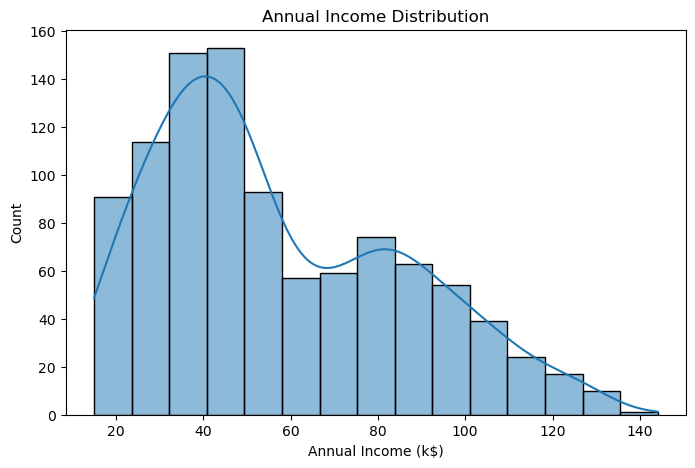

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Annual Income (k$)'], bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.show()

# Observation: 
Annual income is spread across different ranges, showing that customers belong to various income groups.

# Spending Score Distribution

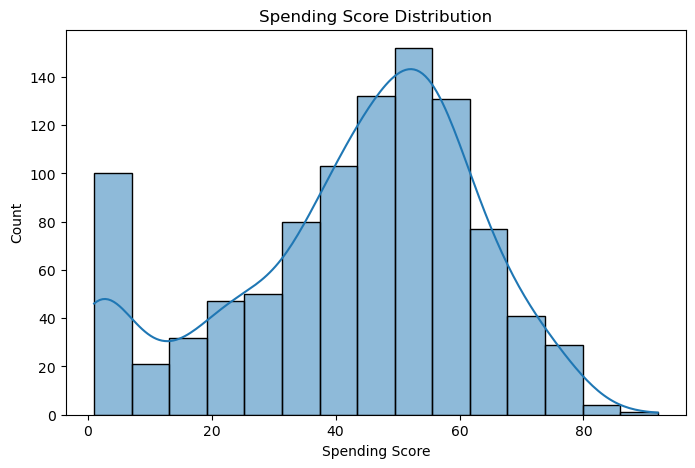

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Spending Score (1-100)'], bins=15, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.show()

# Observation:
Spending scores vary among customers, indicating differences in purchasing behavior.

# Feature Selection

In [19]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,59.9,58.0
1,48.4,37.0
2,70.5,26.0
3,81.1,30.0
4,42.1,58.0


# Observation:

Annual Income and Spending Score are selected as the clustering features because they effectively represent customers' purchasing behavior and spending patterns.

# Standardize the Data

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled[:5]

array([[ 0.09745644,  0.76510194],
       [-0.3051838 , -0.28311966],
       [ 0.46858571, -0.83218813],
       [ 0.83971497, -0.63252687],
       [-0.52576062,  0.76510194]])

# Observation:

The selected features have been standardized so that both contribute equally during clustering. This prevents features with larger values from dominating the clustering process.

# Elbow Method

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

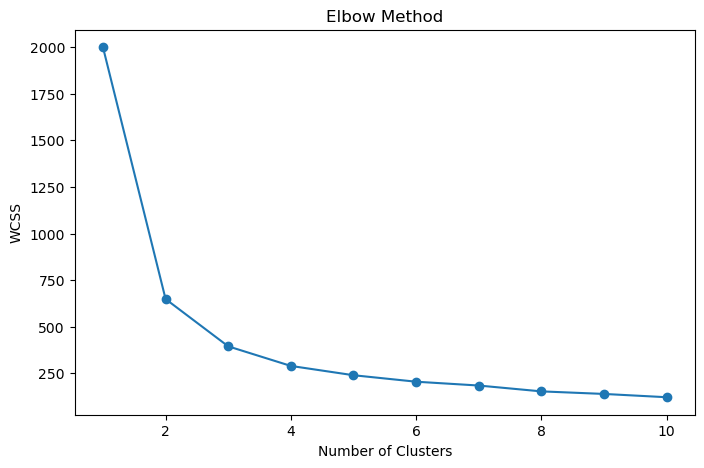

In [22]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Observation:
The Elbow Method is used to identify the optimal number of clusters. The point where the WCSS curve starts to flatten indicates the most suitable value of K.

# Apply K-Means Clustering

In [23]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1000,M,39.0,59.9,58.0,1
1,1001,M,34.0,48.4,37.0,4
2,1002,F,40.0,70.5,26.0,0
3,1003,F,47.0,81.1,30.0,0
4,1004,F,33.0,42.1,58.0,1


# Visualize Customer Clusters

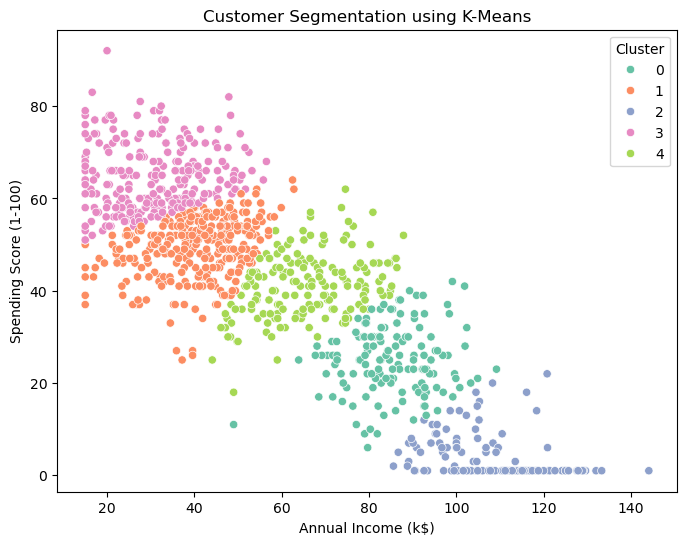

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

# Observation:
The scatter plot shows that customers are divided into different groups based on similar income and spending patterns. Each color represents a different customer segment.

# Profile Each Cluster

In [25]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,85.330769,25.006993
1,40.368810,49.212219
2,108.590083,4.082645
3,30.618474,64.506024
4,65.886932,41.107955


# Observation:
The table shows the average annual income and spending score for each cluster. This helps identify different customer groups based on their purchasing behavior.

# Number of Customers in Each Cluster

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='Cluster', data=df)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

# Observation:
The chart shows how many customers belong to each cluster. It helps understand the distribution of customers across different segments.

## Cluster Profile

In [28]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,85.330769,25.006993
1,40.368810,49.212219
2,108.590083,4.082645
3,30.618474,64.506024
4,65.886932,41.107955


# Marketing Insights

- **Cluster 0:** Customers have high annual income but low spending scores. Personalized promotions, premium product recommendations, and exclusive discounts can encourage them to spend more.

- **Cluster 1:** Customers have moderate income and moderate spending behavior. Regular promotional offers and personalized product suggestions can help maintain their engagement.

- **Cluster 2:** Customers have the highest annual income but the lowest spending scores. These customers have strong purchasing potential, so targeted marketing campaigns and loyalty rewards should be used to increase their spending.

- **Cluster 3:** Customers have low annual income but relatively high spending scores. Affordable product bundles, discounts, and value-for-money offers can help retain these customers.

- **Cluster 4:** Customers have above-average income with moderate spending scores. Personalized recommendations, seasonal offers, and membership benefits can encourage higher purchases.

# Conclusion

This project successfully segmented customers into five distinct groups using the K-Means clustering algorithm based on Annual Income and Spending Score. The analysis identified customers with different purchasing behaviors, enabling businesses to create more effective and personalized marketing strategies.

## Business Recommendations
1. Introduce loyalty programs and personalized offers for high-income customers to increase their spending and improve customer retention.

2. Use targeted promotional campaigns to encourage purchases among customers with high income but low spending scores.

3. Provide affordable product bundles and seasonal discounts for customers with lower income to maintain engagement and improve sales.